
# Evaluation (TEST)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os


plt.style.use("seaborn-v0_8-whitegrid")

palette = {
    "Plastic (own)": "#67be9b",
    "PPO": "#FFAC1C",
    "PPO-Curriculum": "#f1db42",
    "transfer": "#678dbe",
    "scratch": "#dd42f1"
}


## 1) Configurar rutas de CSV

In [2]:

path = "data/test/*.csv"

files = glob.glob(path)

dataframes = []

for file in files:

    df = pd.read_csv(file)

    filename = os.path.basename(file)

    print(filename)

    parts = filename.replace(".csv", "").split("_")

    # =====================================================
    # METHOD
    # =====================================================
    method = parts[2]

    if method.lower() == "plastic":
        method = "Plastic (own)"

    elif method.lower() == "ppo":
        method = "PPO"

    elif method.lower() == "ppo-curriculum":
        method = "PPO-Curriculum"

    # =====================================================
    # SCENARIO
    # =====================================================
    scenario = parts[3]

    # =====================================================
    # CURRICULUM
    # =====================================================
    if method == "PPO-Curriculum":

        # exploration/consolidation
        phase = parts[5]

        # curriculum actual = scratch
        type_ = parts[4]

        df["phase"] = phase

    else:

        # scratch/transfer
        type_ = parts[4]

        df["phase"] = None

    # =====================================================
    # ADD COLUMNS
    # =====================================================
    df["method"] = method
    df["scenario"] = scenario
    df["type"] = type_

    dataframes.append(df)

# =========================================================
# CONCAT
# =========================================================

df_all = pd.concat(
    dataframes,
    ignore_index=True
)

df_all.head()

evaluation_results_plastic_medium_scratch_20260608_074035.csv
evaluation_results_Ppo-curriculum_complex_scratch_exploration_20260512_124606.csv
evaluation_results_plastic_complex_transfer_20260608_074035.csv
evaluation_results_Ppo-curriculum_medium_transfer_consolidation_20260512_124606.csv
evaluation_results_plastic_medium_transfer_20260608_074035.csv
evaluation_results_Ppo-curriculum_complex_transfer_exploration_20260512_124606.csv
evaluation_results_ppo_complex_transfer_20260512_074623.csv
evaluation_results_plastic_complex_scratch_20260608_074035.csv
evaluation_results_ppo_simple_scratch_20260428_064839.csv
evaluation_results_Ppo-curriculum_complex_scratch_consolidation_20260512_124606.csv
evaluation_results_Ppo-curriculum_medium_transfer_exploration_20260512_124606.csv
evaluation_results_Ppo-curriculum_complex_transfer_consolidation_20260512_124606.csv
evaluation_results_ppo_complex_scratch_20260428_064839.csv
evaluation_results_ppo_medium_scratch_20260428_064839.csv
evaluation_re

,episode,success,episode_reward,steps,final_distance,phase,method,scenario,type
0,0,1,675.209231,826,0.299538,None,Plastic (own),medium,scratch
1,1,1,639.995371,782,0.299436,None,Plastic (own),medium,scratch
2,2,1,609.819727,746,0.298984,None,Plastic (own),medium,scratch
3,3,1,582.970397,714,0.299602,None,Plastic (own),medium,scratch
4,4,1,564.555278,692,0.299482,None,Plastic (own),medium,scratch


## 3) Métricas básicas

In [3]:

metrics = df_all.groupby(["method", "type"]).agg({
    "success": "mean",
    "episode_reward": ["mean", "std"],
    "steps": "mean",
    "final_distance": "mean"
})

metrics.columns = ["success_rate", "reward_mean", "reward_std", "steps_mean", "distance_mean"]
metrics = metrics.reset_index()
metrics


,method,type,success_rate,reward_mean,reward_std,steps_mean,distance_mean
0,PPO,scratch,0.053333,1838.539906,1514.844550,2945.813333,1.783322
1,PPO,transfer,0.000000,3131.885066,443.868054,6665.195000,1.441656
2,PPO-Curriculum,scratch,0.193333,935.198929,901.766150,1403.343333,1.576357
3,PPO-Curriculum,transfer,0.065000,428.378060,469.155482,1030.215000,4.155852
4,Plastic (own),scratch,0.946667,573.866993,694.077743,767.493333,0.330587
5,Plastic (own),transfer,0.955000,580.781057,780.749122,791.890000,0.326671


### Transfer autonomy

In [4]:
scratch = metrics[metrics["type"] == "scratch"].set_index("method")
transfer = metrics[metrics["type"] == "transfer"].set_index("method")

scratch["LE"] = scratch["reward_mean"] / scratch["steps_mean"]
transfer["LE"] = transfer["reward_mean"] / transfer["steps_mean"]

scratch["AD"] = scratch["success_rate"]
transfer["AD"] = transfer["success_rate"]

tar = {}
lambda_factor = 0.4

for method in scratch.index:
    le_pre = scratch.loc[method, "LE"]
    ad_pre = scratch.loc[method, "AD"]

    le_post = transfer.loc[method, "LE"]
    ad_post = transfer.loc[method, "AD"]

    tar[method] = (lambda_factor + (le_post * ad_post)) / (lambda_factor + (le_pre * ad_pre))



In [5]:
tar

{'PPO': np.float64(0.923176953106689),
 'PPO-Curriculum': np.float64(0.8074821541496345),
 'Plastic (own)': np.float64(0.9932932606226205)}

## 4) Transfer Ratio (TR)

In [6]:
results_tr = []

for method in df_all["method"].unique():
    for scenario in df_all["scenario"].unique():

        d = df_all[
            (df_all["method"] == method) &
            (df_all["scenario"] == scenario)
        ]

        baseline = d[d["type"] == "scratch"]["episode_reward"].mean()
        transfer = d[d["type"] == "transfer"]["episode_reward"].mean()

        if pd.isna(baseline) or baseline == 0:
            tr = np.nan
        else:
            tr = transfer / baseline

        results_tr.append({
            "method": method,
            "scenario": scenario,
            "TR": tr
        })

df_tr = pd.DataFrame(results_tr)

In [7]:
df_tr

,method,scenario,TR
0,Plastic (own),medium,1.000000
1,Plastic (own),complex,1.000000
2,Plastic (own),simple,NaN
3,PPO-Curriculum,medium,1.169066
4,PPO-Curriculum,complex,0.309568
5,PPO-Curriculum,simple,NaN
6,PPO,medium,0.881581
7,PPO,complex,5.694465
8,PPO,simple,NaN


In [8]:
avg_tr = (
    df_tr.groupby('method', as_index=False)
         .agg(avg_transfer_ratio=('TR', 'mean'))
)

print(avg_tr)

           method  avg_transfer_ratio
0             PPO            3.288023
1  PPO-Curriculum            0.739317
2   Plastic (own)            1.000000


## 5) Gráficas

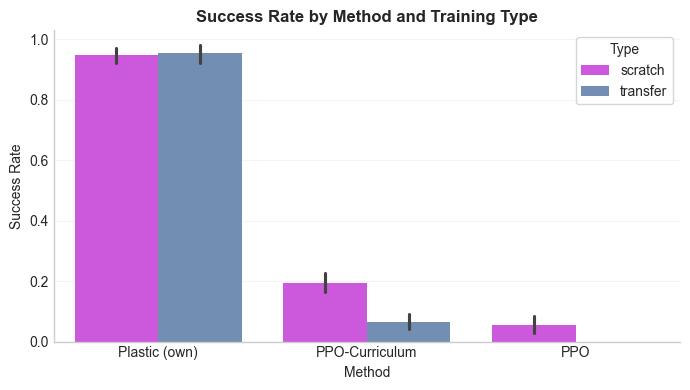

In [9]:
fig, ax = plt.subplots(figsize=(7,4))

sns.barplot(
    data=df_all,
    x="method",
    y="success",
    hue="type",
    estimator=np.mean,
    palette=palette,
    ax=ax
)

ax.set_title("Success Rate by Method and Training Type", fontsize=12, weight='bold')
ax.set_ylabel("Success Rate")
ax.set_xlabel("Method")

ax.grid(axis='y', alpha=0.2)

ax.legend(title="Type", frameon=True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()

fig.savefig(
    "success_rate_evaluation.pdf",
    bbox_inches='tight'
)

plt.show()
plt.close(fig)

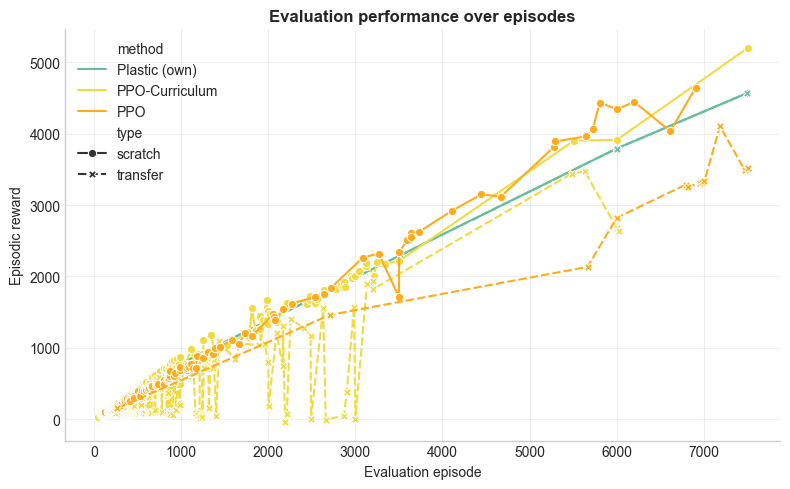

In [10]:
df_all["episode_idx"] = df_all.groupby(["method", "type"]).cumcount()

fig, ax = plt.subplots(figsize=(8,5))

sns.lineplot(
    data=df_all,
    x="steps",
    y="episode_reward",
    hue="method",
    style="type",
    markers=True,
    palette=palette,
    ax=ax
)

# títulos
ax.set_title("Evaluation performance over episodes", fontsize=12, weight='bold')
ax.set_xlabel("Evaluation episode")
ax.set_ylabel("Episodic reward")

# grid suave
ax.grid(alpha=0.3)

# quitar bordes
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# leyenda
# ax.legend(title="Method / Type")

fig.tight_layout()

fig.savefig(
    "evaluation_performance.pdf",
    bbox_inches='tight'
)

plt.show()

# opcional
plt.close(fig)

In [11]:
print(df_all.groupby(["method", "type"]).size())

method          type    
PPO             scratch     300
                transfer    200
PPO-Curriculum  scratch     600
                transfer    400
Plastic (own)   scratch     300
                transfer    200
dtype: int64


## Tabla resumen

In [12]:

summary = df_all.groupby("method").agg({
    "success": "mean",
    "episode_reward": "mean",
    "steps": "mean"
}).reset_index()

summary.columns = ["Method", "Success Rate", "Final Reward", "Avg Steps"]
summary


,Method,Success Rate,Final Reward,Avg Steps
0,PPO,0.032,2355.877970,4433.566
1,PPO-Curriculum,0.142,732.470581,1254.092
2,Plastic (own),0.950,576.632619,777.252
